In [1]:
from src.MOO.moo_initialization import *
from src.MOO.load_data_moo import load_data, load_output
from src.MOO.moo_structures import Individual, Problem
from src.MOO.moo_operators import *
from src.MOO.moo_evolution_algorithm import run_nsga2

In [2]:
import numpy as np

In [3]:
data = load_data('dataset/hustack/input/rc_201.1.txt')
best_solution = load_output('dataset/hustack/input/rc_201.1.txt', 'dataset/hustack/output/rc201.1-bestSolution.txt')

In [4]:
problem = Problem(num_request=data[0],
                  request=data[1], 
                  time_matrix=np.array(data[2]))

In [5]:
cal_moo_fitness([best_solution])

In [6]:
print("---> Fittest individual: ", best_solution.fitness)
print("-----Corresponding to the best individual-----")
print("---> Route:",  best_solution.route)

# Index 3: Total time (Scalar)
print("---> Total service time: ", best_solution.route_computing[3]) 

print("---> Total travel time: ", sum(best_solution.route_computing[0])) 
# Index 4: Lateness (List) -> dùng để đếm số lần vi phạm
print("Number of time window violations: ", sum(1 for x in best_solution.route_computing[4] if x != 0.0))

# Index 5: Total Lateness (Scalar)
print("Total time of late arrivals: ", best_solution.route_computing[5])

# Index 6: Wait (List) -> dùng để đếm số lần đến sớm
print("Number of arrivals ealier than opening time: ", sum(1 for x in best_solution.route_computing[6] if x != 0))

# Index 7: Total Wait (Scalar)
print("Total time of arrivals ealier than opening time:", best_solution.route_computing[7])

---> Fittest individual:  (np.float64(342.2956), np.float64(93.45420000000007))
-----Corresponding to the best individual-----
---> Route: [13, 14, 18, 4, 9, 5, 7, 8, 6, 16, 19, 17, 1, 11, 3, 12, 10, 2, 15]
---> Total service time:  592.0611
---> Total travel time:  342.2956
Number of time window violations:  0
Total time of late arrivals:  0.0
Number of arrivals ealier than opening time:  4
Total time of arrivals ealier than opening time: 46.727100000000036


In [7]:
# gen_type = 'random'
# gen_type = 'greedy'
pop_size = 100
c_rate = 0.8
m_rate = 0.2
generations = 500
maximum_loop =150

In [8]:
params ={
    "cmethod": 'ox', # ox, pmx, cx
    "mmethod": 'swap', # inversion, swap, scramble
    "tourn_s_parameter": 2, # dùng cho tournament trong select_parents
    
    "gen_type": 'greedy', # loại khởi tạo greedy
    "greedy_rate": 0.5, # tỉ lệ các cá thể được khởi tạo greedy trong quần thể ban đầu
    "search_size": 2, # số lượng hàng xóm xét tại mỗi điểm đang đứng mà sẽ lựa chọn một trong số chúng để đến trong lộ trình tham lam
    # "imp_type": 'first_improvement',
    # "ls_rate" : 0.1
}

In [9]:
# last_pop = run_nsga2(problem, pop_size, c_rate, m_rate, generations, maximum_loop, **params)


In [10]:
import matplotlib.pyplot as plt 

Running NSGA-II...
Starting NSGA-II for Multi-Objective Optimization...
Initial fitness (Best Obj 1): 229.0296


Gen: 0 | Pareto size: 9 | Min Travel Time: 229.0296 | Min Violation: 239.89739999999972
Gen: 20 | Pareto size: 11 | Min Travel Time: 225.68639999999996 | Min Violation: 63.72659999999985
Gen: 40 | Pareto size: 11 | Min Travel Time: 222.63959999999997 | Min Violation: 63.72659999999985
Gen: 60 | Pareto size: 14 | Min Travel Time: 222.1964 | Min Violation: 53.95839999999987
Gen: 80 | Pareto size: 12 | Min Travel Time: 222.1964 | Min Violation: 53.95839999999987
Gen: 100 | Pareto size: 13 | Min Travel Time: 221.6398 | Min Violation: 53.95839999999987
Gen: 120 | Pareto size: 15 | Min Travel Time: 221.6398 | Min Violation: 53.95839999999987
Gen: 140 | Pareto size: 14 | Min Travel Time: 219.4743 | Min Violation: 53.95839999999987
Gen: 160 | Pareto size: 16 | Min Travel Time: 219.4743 | Min Violation: 0.0
Gen: 180 | Pareto size: 18 | Min Travel Time: 219.4743 | Min Violation: 0.0
Gen: 200 | Pareto size: 18 | Min Travel Time: 219.4743 | Min Violation: 0.0
Gen: 220 | Pareto size: 19 | Min Trave

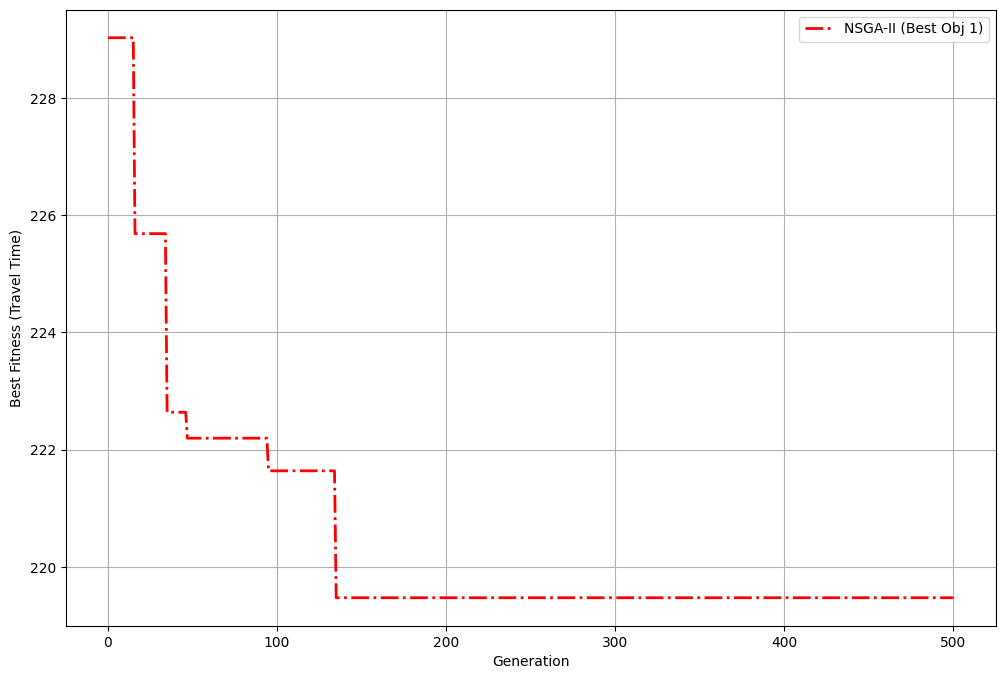

In [11]:
plt.figure(figsize=(12, 8))
print("Running NSGA-II...")
pop_nsga, progress_nsga = run_nsga2(problem, pop_size, c_rate, m_rate, generations, maximum_loop, **params)
plt.plot(progress_nsga, label='NSGA-II (Best Obj 1)', color='red', linewidth=2, linestyle='-.')
# plt.title('Comparison of Algorithms Convergence')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (Travel Time)')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# plt.plot(progress_nsga, label='NSGA-II (Best Obj 1)', color='red', linewidth=2, linestyle='-.')

In [13]:
for i, indi in enumerate(pop_nsga):
    print(i, indi.fitness[0], indi.fitness[1], indi.route_computing[5], indi.route_computing[7])

0 405.8824 0.0 0.0 0.0
1 219.4743 30386.645600000007 7320.1806000000015 552.9616
2 221.6398 18032.105399999993 4303.207099999999 409.6385
3 222.63959999999997 13876.999000000002 3295.5594000000006 347.38070000000005
4 252.4622 8529.0564 1984.3883999999998 295.7514
5 372.2307 53.95839999999987 0.0 26.979199999999935
6 289.2425999999999 2147.884 470.7282 132.48559999999995
7 338.29279999999994 133.4543999999999 0.0 66.72719999999995
8 382.24399999999997 13.557400000000143 0.0 6.778700000000072
9 309.527 1149.0705999999998 242.10849999999994 90.31830000000002
10 274.9552 4669.606600000001 1067.8654000000001 199.07250000000008
11 264.2135 6561.290600000002 1521.7840000000006 237.07729999999992
12 262.3918 7158.354400000001 1679.7379000000003 219.70139999999998
13 283.7582 3983.4600000000005 922.4618000000002 146.8064
14 313.96359999999993 638.3451999999997 106.04539999999997 107.08179999999996
15 323.6667 496.4756 78.30150000000003 91.63479999999993
16 327.51259999999996 488.78380000000004

In [14]:
best_indi = min(pop_nsga, key = lambda x: x.fitness[1])
print(best_indi.fitness[0])
print(best_indi.route)

405.8824
[14, 13, 9, 18, 4, 5, 6, 8, 7, 17, 16, 11, 1, 19, 3, 12, 10, 2, 15]


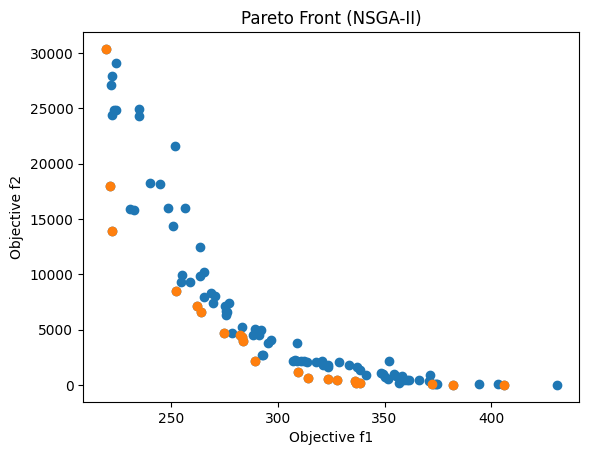

In [ ]:
import matplotlib.pyplot as plt

# Parse data: id, f1, f2 (ignore remaining columns)
raw_data = """
0 405.8824 0.0
1 219.4743 30386.645600000007
2 221.6398 18032.105399999993
3 222.63959999999997 13876.999000000002
4 252.4622 8529.0564
5 372.2307 53.95839999999987
6 289.2425999999999 2147.884
7 338.29279999999994 133.4543999999999
8 382.24399999999997 13.557400000000143
9 309.527 1149.0705999999998
10 274.9552 4669.606600000001
11 264.2135 6561.290600000002
12 262.3918 7158.354400000001
13 283.7582 3983.4600000000005
14 313.96359999999993 638.3451999999997
15 323.6667 496.4756
16 327.51259999999996 488.78380000000004
17 336.04049999999995 385.283
18 282.1905 4496.140199999999
19 283.17639999999994 4355.948600000001
20 336.5422 136.9555999999999
21 430.5293 0.0
22 222.15119999999996 27145.320200000002
23 222.29689999999997 24440.939399999992
24 230.79229999999998 15921.018199999999
25 251.17530000000005 14394.3906
26 394.2507 53.95839999999987
27 254.79689999999997 9326.5662
28 232.49610000000004 15827.485400000003
29 278.7776 4714.388000000001
30 265.4881 7920.794199999998
31 356.7509 133.97259999999943
32 275.6992 6347.5149999999985
33 258.7483 9300.948399999997
34 374.22389999999996 61.59219999999982
35 307.2407 2165.5294
36 292.92199999999997 2691.9257999999995
37 373.1567 63.72659999999985
38 291.13660000000004 4478.248
39 337.1564 1583.09
40 341.542 935.3262000000002
41 269.8839 7392.3596
42 292.7142 2742.2321999999995
43 323.60339999999997 1611.8641999999993
44 288.2758 4502.407999999999
45 275.46399999999994 7114.724
46 350.0043 719.1512
47 313.7055 2047.0649999999996
48 321.4197 1845.8754
49 351.6128 511.72800000000126
50 338.6493 1349.9023999999995
51 310.7845 2129.0163999999995
52 323.4042999999999 1790.2559999999999
53 309.02989999999994 2161.951
54 374.3147 80.56119999999999
55 222.1964 27965.427399999993
56 248.667 16038.960600000004
57 235.209 24331.083399999996
58 255.10309999999996 9911.370800000002
59 240.0761 18290.837
60 295.4487 3769.197
61 308.07829999999996 2231.9318
62 333.33439999999996 1782.4256
63 263.65290000000005 9856.378399999998
64 283.3879999999999 5255.794999999998
65 244.8464 18212.981000000003
66 348.3902 1033.166800000001
67 223.21229999999997 24903.902199999997
68 328.8109 2060.6865999999995
69 317.86379999999997 2114.8577999999998
70 268.89609999999993 8309.519200000002
71 270.4308 8012.9364
72 276.17529999999994 6635.7278
73 224.24189999999996 24848.3302
74 275.9466 6670.892999999999
75 292.18769999999995 4993.049800000002
76 312.1836 2155.6436
77 289.2802 5062.0098000000025
78 366.2792 411.2506000000001
79 370.8177 324.5007999999997
80 354.35369999999995 994.6519999999996
81 349.0716 1020.5838000000006
82 361.34839999999997 421.11220000000003
83 358.319 770.3399999999998
84 355.16530000000006 776.6473999999998
85 359.2041 425.4008
86 360.2812 423.24659999999994
87 403.13210000000004 118.01520000000028
88 224.39179999999993 29076.4136
89 251.93329999999997 21627.919999999995
90 235.10719999999998 24959.925
91 277.08590000000004 7409.4908
92 256.7851 15993.350799999995
93 371.1281 876.6038000000001
94 352.18639999999994 2137.2346
95 296.80850000000004 4081.9716
96 320.817 2169.6725999999994
97 263.8477 12449.3652
98 265.53469999999993 10184.204399999999
99 308.86179999999996 3756.4053999999987
"""

data = []
for line in raw_data.strip().splitlines():
    i, f1, f2 = map(float, line.split())
    data.append((int(i), f1, f2))

# Identify Pareto front (minimization)
pareto = []
for i, f1, f2 in data:
    dominated = False
    for j, g1, g2 in data:
        if (g1 <= f1 and g2 <= f2) and (g1 < f1 or g2 < f2):
            dominated = True
            break
    if not dominated:
        pareto.append((i, f1, f2))


# Plot
plt.figure()
plt.scatter([d[1] for d in data], [d[2] for d in data])
plt.scatter([p[1] for p in pareto], [p[2] for p in pareto])
plt.xlabel("Objective f1")
plt.ylabel("Objective f2")
plt.title("Pareto Front (NSGA-II)")
plt.show()


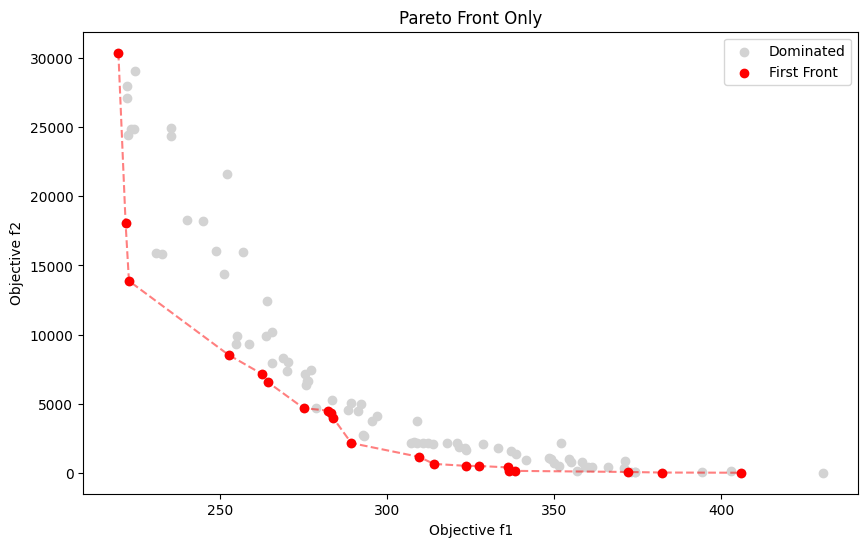

In [5]:
import matplotlib.pyplot as plt

# (Phần raw_data giữ nguyên như cũ)
raw_data = """
0 405.8824 0.0
1 219.4743 30386.645600000007
2 221.6398 18032.105399999993
3 222.63959999999997 13876.999000000002
4 252.4622 8529.0564
5 372.2307 53.95839999999987
6 289.2425999999999 2147.884
7 338.29279999999994 133.4543999999999
8 382.24399999999997 13.557400000000143
9 309.527 1149.0705999999998
10 274.9552 4669.606600000001
11 264.2135 6561.290600000002
12 262.3918 7158.354400000001
13 283.7582 3983.4600000000005
14 313.96359999999993 638.3451999999997
15 323.6667 496.4756
16 327.51259999999996 488.78380000000004
17 336.04049999999995 385.283
18 282.1905 4496.140199999999
19 283.17639999999994 4355.948600000001
20 336.5422 136.9555999999999
21 430.5293 0.0
22 222.15119999999996 27145.320200000002
23 222.29689999999997 24440.939399999992
24 230.79229999999998 15921.018199999999
25 251.17530000000005 14394.3906
26 394.2507 53.95839999999987
27 254.79689999999997 9326.5662
28 232.49610000000004 15827.485400000003
29 278.7776 4714.388000000001
30 265.4881 7920.794199999998
31 356.7509 133.97259999999943
32 275.6992 6347.5149999999985
33 258.7483 9300.948399999997
34 374.22389999999996 61.59219999999982
35 307.2407 2165.5294
36 292.92199999999997 2691.9257999999995
37 373.1567 63.72659999999985
38 291.13660000000004 4478.248
39 337.1564 1583.09
40 341.542 935.3262000000002
41 269.8839 7392.3596
42 292.7142 2742.2321999999995
43 323.60339999999997 1611.8641999999993
44 288.2758 4502.407999999999
45 275.46399999999994 7114.724
46 350.0043 719.1512
47 313.7055 2047.0649999999996
48 321.4197 1845.8754
49 351.6128 511.72800000000126
50 338.6493 1349.9023999999995
51 310.7845 2129.0163999999995
52 323.4042999999999 1790.2559999999999
53 309.02989999999994 2161.951
54 374.3147 80.56119999999999
55 222.1964 27965.427399999993
56 248.667 16038.960600000004
57 235.209 24331.083399999996
58 255.10309999999996 9911.370800000002
59 240.0761 18290.837
60 295.4487 3769.197
61 308.07829999999996 2231.9318
62 333.33439999999996 1782.4256
63 263.65290000000005 9856.378399999998
64 283.3879999999999 5255.794999999998
65 244.8464 18212.981000000003
66 348.3902 1033.166800000001
67 223.21229999999997 24903.902199999997
68 328.8109 2060.6865999999995
69 317.86379999999997 2114.8577999999998
70 268.89609999999993 8309.519200000002
71 270.4308 8012.9364
72 276.17529999999994 6635.7278
73 224.24189999999996 24848.3302
74 275.9466 6670.892999999999
75 292.18769999999995 4993.049800000002
76 312.1836 2155.6436
77 289.2802 5062.0098000000025
78 366.2792 411.2506000000001
79 370.8177 324.5007999999997
80 354.35369999999995 994.6519999999996
81 349.0716 1020.5838000000006
82 361.34839999999997 421.11220000000003
83 358.319 770.3399999999998
84 355.16530000000006 776.6473999999998
85 359.2041 425.4008
86 360.2812 423.24659999999994
87 403.13210000000004 118.01520000000028
88 224.39179999999993 29076.4136
89 251.93329999999997 21627.919999999995
90 235.10719999999998 24959.925
91 277.08590000000004 7409.4908
92 256.7851 15993.350799999995
93 371.1281 876.6038000000001
94 352.18639999999994 2137.2346
95 296.80850000000004 4081.9716
96 320.817 2169.6725999999994
97 263.8477 12449.3652
98 265.53469999999993 10184.204399999999
99 308.86179999999996 3756.4053999999987
"""

data = []
for line in raw_data.strip().splitlines():
    i, f1, f2 = map(float, line.split())
    data.append((int(i), f1, f2))

# Identify Pareto front (minimization)
pareto = []
for i, f1, f2 in data:
    dominated = False
    for j, g1, g2 in data:
        if i == j: continue
        # Điều kiện: g tốt hơn hoặc bằng f ở mọi mặt, và tốt hơn hẳn ít nhất 1 mặt
        if (g1 <= f1 and g2 <= f2) and (g1 < f1 or g2 < f2):
            dominated = True
            break
    if not dominated:
        pareto.append((i, f1, f2))

# Sắp xếp để vẽ đường nối đẹp hơn
pareto.sort(key=lambda x: x[1])

# Plot
plt.figure(figsize=(10, 6))
# Vẽ các điểm bị trội mờ đi để làm nền (hoặc xóa dòng này nếu muốn ẩn hoàn toàn)
plt.scatter([d[1] for d in data], [d[2] for d in data], color='lightgrey', label='Dominated')

# Vẽ Front đầu tiên nổi bật
p_f1 = [p[1] for p in pareto]
p_f2 = [p[2] for p in pareto]
plt.plot(p_f1, p_f2, color='red', linestyle='--', alpha=0.5)
plt.scatter(p_f1, p_f2, color='red', label='First Front')

# Hiển thị ID của các điểm trên Front
# for p in pareto:
#     plt.annotate(str(p[0]), (p[1], p[2]), xytext=(5, 5), textcoords='offset points')

plt.xlabel("Objective f1")
plt.ylabel("Objective f2")
plt.title("Pareto Front Only")
plt.legend()
plt.show()